In [36]:
import pandas as pd # Импортируем библиотеку Pandas для работы с данными в формате DataFrame
import numpy as np # Импортируем библиотеку NumPy для работы с числовыми данными

from sklearn.datasets import fetch_california_housing # Импортируем функцию fetch_california_housing из sklearn.datasets для загрузки датасета California Housing

from sklearn.model_selection import train_test_split # Импортируем функцию train_test_split из sklearn.model_selection для разделения данных на тренировочный и тестовый наборы

from sklearn.linear_model import HuberRegressor # Импортируем класс HuberRegressor из sklearn.linear_model для реализации регрессии методом Хьюбера
from sklearn.linear_model import LinearRegression # Импортируем класс LinearRegression из sklearn.linear_model для реализации линейной регрессии
from sklearn.preprocessing import PolynomialFeatures # Импортируем класс PolynomialFeatures из sklearn.preprocessing для генерации полиномиальных признаков
from sklearn.metrics import mean_squared_error # Импортируем функцию mean_squared_error из sklearn.metrics для вычисления среднеквадратичной ошибки

from sklearn.preprocessing import StandardScaler # Импортируем класс StandardScaler из sklearn.preprocessing для стандартизации данных

import matplotlib.pyplot as plt # Импортируем модуль pyplot из библиотеки matplotlib для построения графиков
import seaborn as sns # Импортируем библиотеку seaborn для улучшения визуализации данных

In [37]:
pd.set_option('display.max_columns', 50) # Устанавливаем максимальное количество отображаемых столбцов равным 50
pd.set_option('display.max_rows', 20) # Устанавливаем максимальное количество отображаемых строк равным 20
pd.options.display.float_format = '{:.2f}'.format # Устанавливаем формат отображения чисел с двумя знаками после запятой
pd.options.mode.use_inf_as_na = True # Настройка режима Pandas для рассмотрения бесконечностей (inf) как пропущенных значений (NA)

# Конфигурация формата отображения графиков в виде векторных изображений
%config InlineBackend.figure_format = 'svg'

**Линейная регрессия** &mdash; это модель следующего вида:
$$a(x) = \langle w, x \rangle + w_0$$
где $w \in \mathbb{R}^d$, $w_0 \in \mathbb{R}$. Обучить линейную регрессию &mdash; значит найти $w = [w_1, w_2, ... , w_n]$ и $w_0$.

## Рассмотрим пример с выбросами в данных

In [38]:
# Создание случайных данных с выбросами
np.random.seed(0)
n_samples = 100
X = np.random.rand(n_samples, 1) * 10
y = 2 * X.squeeze() + np.random.randn(n_samples) * 2
# Добавление выбросов
X[95:] = 10
y[95:] = -50

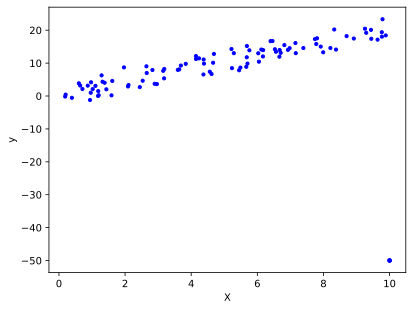

In [39]:
# Построение графика
plt.scatter(X, y, color='blue', label='Data', s=10)

plt.xlabel('X')
plt.ylabel('y')
plt.show()

**Loss function**

$L(y, y_{pred}) = MSE = \frac{1}{N}\sum_{i=1}^N(y_i - y_i^{pred})^2, $

In [40]:
# Линейная регрессия с MSE
reg_mse = LinearRegression()
reg_mse.fit(X, y)


LinearRegression()

**Loss function**

$L(y, y_{pred}) = \begin{cases}
\sum_{i=1}^N(\frac{1}{2}(y_i - y_i^{\text{pred}})^2, если  |y_i - y_i^{\text{pred}}| \leq \epsilon \\
\sum_{i=1}^N\epsilon|y_i - y_i^{\text{pred}}| - \frac{1}{2}\epsilon^2, если |y_i - y_i^{\text{pred}}| > \epsilon \\
\end{cases}$

In [41]:
# Линейная регрессия с Huber функцией
reg_huber = HuberRegressor(epsilon=1.35)
reg_huber.fit(X, y)

HuberRegressor()

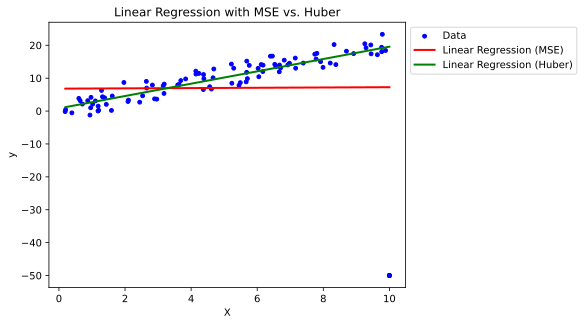

In [42]:
# Построение графика
plt.scatter(X, y, color='blue', label='Data', s=15)
plt.plot(X, reg_mse.predict(X), color='red', linewidth=2, label='Linear Regression (MSE)')
plt.plot(X, reg_huber.predict(X), color='green', linewidth=2, label='Linear Regression (Huber)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression with MSE vs. Huber')
plt.show()

## Полиномиальная регрессия

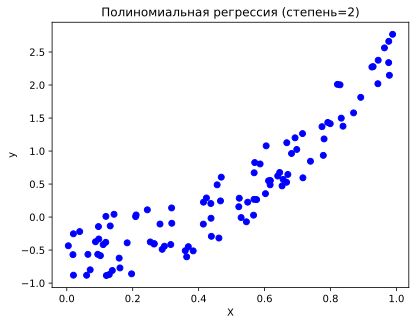

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Создание синтетических данных
np.random.seed(0)
X = np.random.rand(100, 1)
y = 3 * X**2  - np.random.rand(100, 1)

# Визуализация результатов
plt.scatter(X, y, color='blue')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Полиномиальная регрессия (степень=2)')
plt.show()


In [44]:


# Преобразование в матрицу признаков с полиномиальными признаками
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

# Обучение модели полиномиальной регрессии
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)
y_pred_poly = poly_reg.predict(X_poly)


In [45]:
# Обучение модели полиномиальной регрессии
lin_reg = LinearRegression()
lin_reg.fit(X, y)

LinearRegression()

In [46]:
y_pred_lin = lin_reg.predict(X)

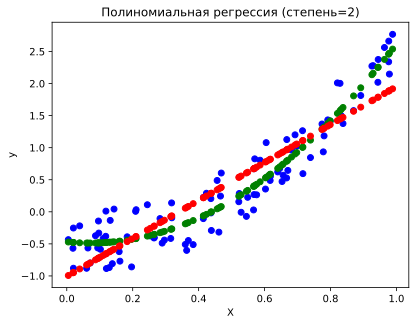

In [47]:
# Визуализация результатов
plt.scatter(X, y, color='blue')
plt.scatter(X, y_pred_poly, color='green')
plt.scatter(X, y_pred_lin, color='red')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Полиномиальная регрессия (степень=2)')
plt.show()

## Логистическая регрессия

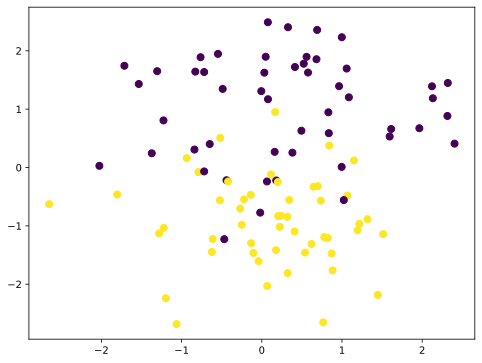

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

# Генерируем синтетические данные с линейно разделимыми классами
X, y = make_classification(n_samples=100, n_classes=2, random_state=42)


plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y,  s=50);

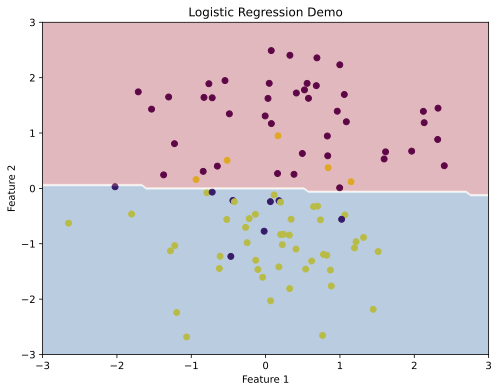

In [63]:

# Создаем экземпляр модели логистической регрессии
model = LogisticRegression()

# Обучаем модель на данных
model.fit(X[:,[0,1]], y)

# Визуализируем данные и границу принятия решений
plt.figure(figsize=(8, 6))

# Визуализируем точки данных
plt.scatter(X[:, 0], X[:, 1], c=y)

# Создаем сетку для визуализации границы принятия решений
xx, yy = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

# Визуализируем границу принятия решений
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.3)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Demo')
plt.show()
